In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle, resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
import joblib

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load dataset
csv_path = "/content/drive/MyDrive/dataset/TESS_audio_features.csv"
df = pd.read_csv(csv_path)
df.head()

,Filename,Emotion,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,...,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26,Feature_27,Feature_28,Feature_29,Feature_30,Feature_31
0,OAF_back_fear.wav,Anxiety,-434.416840,61.591835,1.869825,-8.288072,2.913275,3.220161,-13.606009,-0.346508,...,0.273205,0.324255,0.318041,22.794704,23.213973,22.891643,20.558654,21.470778,18.120759,47.596309
1,OAF_bar_fear.wav,Anxiety,-433.824646,70.088837,12.938360,-21.756363,-6.834160,4.844457,-11.890791,-0.407226,...,0.253846,0.249001,0.219839,23.353286,26.443642,25.250553,24.431355,23.146356,19.086337,49.779701
2,OAF_base_fear.wav,Anxiety,-443.532318,38.710720,11.385891,5.367714,8.344028,0.096640,-12.813403,-2.515016,...,0.243166,0.244979,0.269832,23.348135,23.821711,22.571743,21.466647,21.368319,19.181027,48.128395
3,OAF_bath_fear.wav,Anxiety,-405.627777,61.299316,7.477961,-13.963837,-1.340553,2.632162,-11.384148,-0.700052,...,0.269471,0.324412,0.337801,22.005249,22.642810,22.914293,20.868673,21.807456,18.942595,47.906213
4,OAF_bean_fear.wav,Anxiety,-491.337769,53.490482,20.951565,8.448865,8.880781,0.637741,-6.358855,1.899915,...,0.178721,0.258132,0.348966,23.815119,24.274177,23.111718,21.260854,21.147717,19.359906,47.490657


In [ ]:
# Display dataset info
print("Dataset Overview:")
df.info()

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Filename    2800 non-null   object 
 1   Emotion     2800 non-null   object 
 2   Feature_0   2800 non-null   float64
 3   Feature_1   2800 non-null   float64
 4   Feature_2   2800 non-null   float64
 5   Feature_3   2800 non-null   float64
 6   Feature_4   2800 non-null   float64
 7   Feature_5   2800 non-null   float64
 8   Feature_6   2800 non-null   float64
 9   Feature_7   2800 non-null   float64
 10  Feature_8   2800 non-null   float64
 11  Feature_9   2800 non-null   float64
 12  Feature_10  2800 non-null   float64
 13  Feature_11  2800 non-null   float64
 14  Feature_12  2800 non-null   float64
 15  Feature_13  2800 non-null   float64
 16  Feature_14  2800 non-null   float64
 17  Feature_15  2800 non-null   float64
 18  Feature_16  2800 non-null   float64
 19  Feature_1

In [ ]:
# Count the number of samples per emotion category
emotion_counts = df["Emotion"].value_counts()
print("\nSample Counts per Emotion:\n", emotion_counts)


Sample Counts per Emotion:
 Emotion
Normal        1600
Depression     800
Anxiety        400
Name: count, dtype: int64


<ipython-input-5-3a609695e6b1>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="coolwarm")


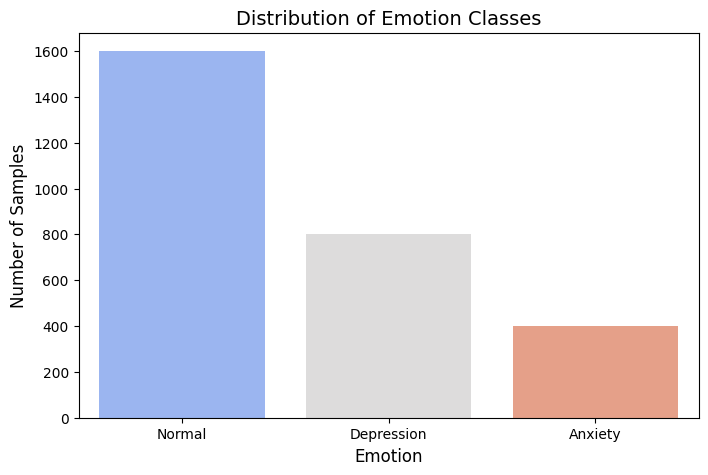

In [ ]:
# Plot the distribution of emotions
plt.figure(figsize=(8, 5))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="coolwarm")
plt.xlabel("Emotion", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.title("Distribution of Emotion Classes", fontsize=14)
plt.show()

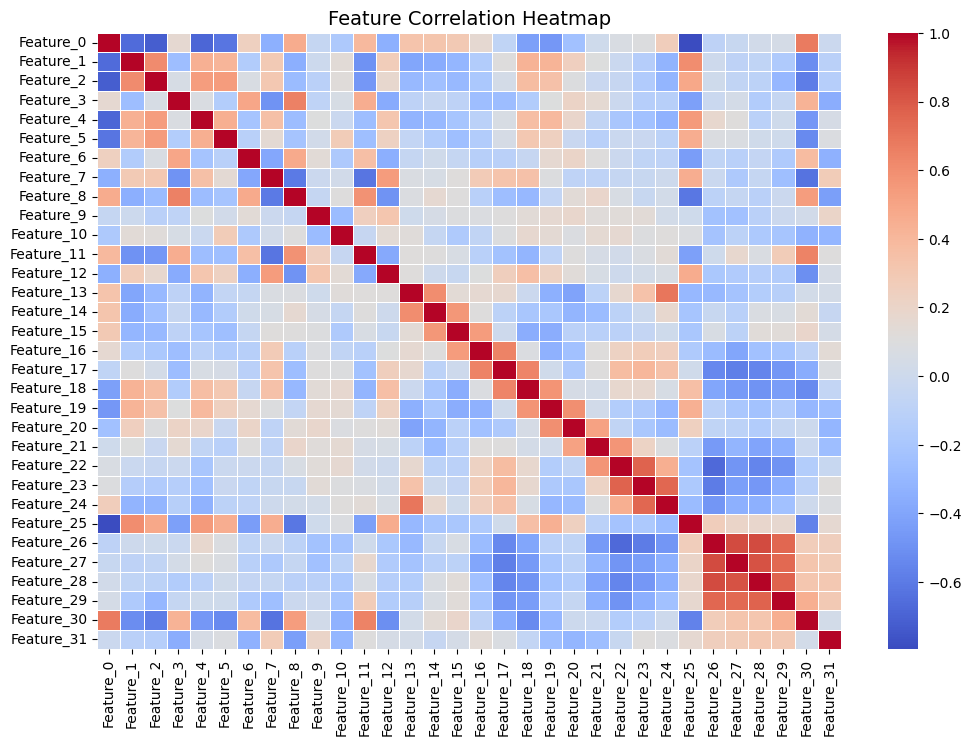

In [ ]:
# Compute correlation matrix
correlation_matrix = df.iloc[:, 2:].corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()


In [ ]:
# Identify features with high correlation (> 0.8)
high_corr_features = set()
threshold = 0.8

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            feature1 = correlation_matrix.columns[i]
            feature2 = correlation_matrix.columns[j]
            high_corr_features.add((feature1, feature2))

print("Highly Correlated Feature Pairs:")
for pair in high_corr_features:
    print(pair)


Highly Correlated Feature Pairs:
('Feature_28', 'Feature_27')
('Feature_27', 'Feature_26')
('Feature_28', 'Feature_26')


In [ ]:
# Shuffle the dataset
df = shuffle(df, random_state=42)

# Balance the dataset using resampling
balanced_df = pd.DataFrame()
min_samples = df["Emotion"].value_counts().min()

for emotion in df["Emotion"].unique():
    subset = df[df["Emotion"] == emotion]
    subset_balanced = resample(subset, replace=False, n_samples=min_samples, random_state=42)
    balanced_df = pd.concat([balanced_df, subset_balanced])

b_emotion_counts = balanced_df["Emotion"].value_counts()
print("\nBalanced Dataset Sample Counts:")
print(balanced_df["Emotion"].value_counts())


Balanced Dataset Sample Counts:
Emotion
Normal        400
Anxiety       400
Depression    400
Name: count, dtype: int64


<ipython-input-10-b9d6d3ba85d8>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=b_emotion_counts.index, y=b_emotion_counts.values, palette="coolwarm")


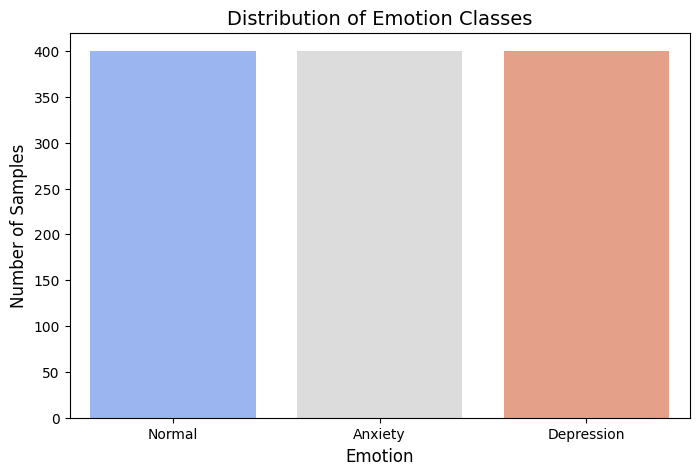

In [ ]:
# Plot the distribution of emotions
plt.figure(figsize=(8, 5))
sns.barplot(x=b_emotion_counts.index, y=b_emotion_counts.values, palette="coolwarm")
plt.xlabel("Emotion", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.title("Distribution of Emotion Classes", fontsize=14)
plt.show()

In [ ]:
# Extract features and labels
X = balanced_df.iloc[:, 2:].values
y = balanced_df["Emotion"].values

# Encode labels
encoder = LabelEncoder()
y = encoder.fit_transform(y)
y_categorical = to_categorical(y)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Save the scaler for later use in testing
scaler_path = "/content/drive/MyDrive/dataset/scaler.pkl"
joblib.dump(scaler, scaler_path)

# Save the label encoder
encoder_path = "/content/drive/MyDrive/dataset/encoder.pkl"
joblib.dump(encoder, encoder_path)

print("✅Scaler & Label encoder saved successfully!")

✅Scaler & Label encoder saved successfully!


In [ ]:
# Reshape for Conv1D
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical)

print("✅ Data Preprocessing Completed!")
print(f"Input Shape for CNN: {X_train.shape}")

✅ Data Preprocessing Completed!
Input Shape for CNN: (960, 32, 1)


In [ ]:
### 🎯 **Train Models**

# Initialize models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
svm_model = SVC(kernel="rbf", probability=True, random_state=42)

In [ ]:
# Train Random Forest
rf_model.fit(X_train.reshape(X_train.shape[0], X_train.shape[1]), np.argmax(y_train, axis=1))
y_pred_rf = rf_model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1]))
rf_acc = accuracy_score(np.argmax(y_test, axis=1), y_pred_rf)

In [ ]:
# Train SVM
svm_model.fit(X_train.reshape(X_train.shape[0], X_train.shape[1]), np.argmax(y_train, axis=1))
y_pred_svm = svm_model.predict(X_test.reshape(X_test.shape[0], X_test.shape[1]))
svm_acc = accuracy_score(np.argmax(y_test, axis=1), y_pred_svm)

In [ ]:
# Define CNN model
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation="relu", input_shape=(X_train.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=128, kernel_size=3, activation="relu"),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=256, kernel_size=3, activation="relu"),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(len(encoder.classes_), activation="softmax")
])

# Compile CNN
cnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Train CNN
history = cnn_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=50, batch_size=32)
cnn_acc = max(history.history["val_accuracy"])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.5497 - loss: 1.2515 - val_accuracy: 0.6667 - val_loss: 0.9397
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8620 - loss: 0.3593 - val_accuracy: 0.5292 - val_loss: 1.0453
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8803 - loss: 0.2886 - val_accuracy: 0.6125 - val_loss: 1.0402
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9029 - loss: 0.2443 - val_accuracy: 0.6417 - val_loss: 1.1186
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9181 - loss: 0.2270 - val_accuracy: 0.4958 - val_loss: 1.4152
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9467 - loss: 0.1449 - val_accuracy: 0.6083 - val_loss: 1.2796
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9584 - loss: 0.1225 - val_accuracy: 0.6333 - val_loss: 1.1471
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9540 - loss: 0.1219 - val_accuracy: 0.6500 - 

In [ ]:
### 📊 **Model Evaluation**
print("\n📌 Classification Reports:\n")

# Random Forest
print("\n🔹 Random Forest:")
print(classification_report(np.argmax(y_test, axis=1), y_pred_rf, target_names=encoder.classes_))



📌 Classification Reports:


🔹 Random Forest:
              precision    recall  f1-score   support

     Anxiety       0.99      1.00      0.99        80
  Depression       0.95      1.00      0.98        80
      Normal       1.00      0.94      0.97        80

    accuracy                           0.98       240
   macro avg       0.98      0.98      0.98       240
weighted avg       0.98      0.98      0.98       240



In [ ]:
# SVM
print("\n🔹 SVM:")
print(classification_report(np.argmax(y_test, axis=1), y_pred_svm, target_names=encoder.classes_))




🔹 SVM:
              precision    recall  f1-score   support

     Anxiety       1.00      1.00      1.00        80
  Depression       0.98      1.00      0.99        80
      Normal       1.00      0.97      0.99        80

    accuracy                           0.99       240
   macro avg       0.99      0.99      0.99       240
weighted avg       0.99      0.99      0.99       240



In [ ]:
# CNN Predictions
y_pred_cnn = cnn_model.predict(X_test)
y_pred_cnn_labels = np.argmax(y_pred_cnn, axis=1)
cnn_report = classification_report(np.argmax(y_test, axis=1), y_pred_cnn_labels, target_names=encoder.classes_)
print("\n🔹 CNN:")
print(cnn_report)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

🔹 CNN:
              precision    recall  f1-score   support

     Anxiety       1.00      0.99      0.99        80
  Depression       0.98      1.00      0.99        80
      Normal       1.00      0.99      0.99        80

    accuracy                           0.99       240
   macro avg       0.99      0.99      0.99       240
weighted avg       0.99      0.99      0.99       240



In [ ]:
# Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

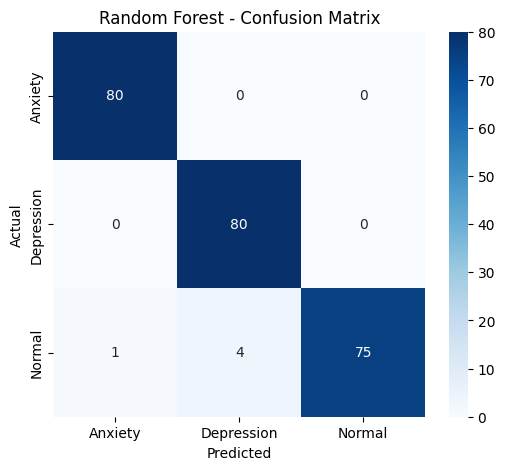

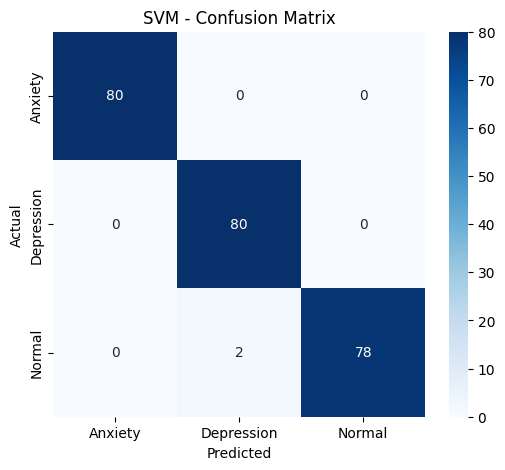

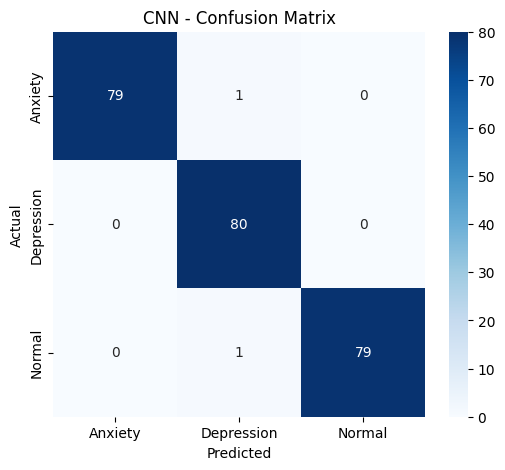

In [ ]:
plot_confusion_matrix(np.argmax(y_test, axis=1), y_pred_rf, "Random Forest - Confusion Matrix")
plot_confusion_matrix(np.argmax(y_test, axis=1), y_pred_svm, "SVM - Confusion Matrix")
plot_confusion_matrix(np.argmax(y_test, axis=1), y_pred_cnn_labels, "CNN - Confusion Matrix")

In [ ]:
### 🏆 **Compare Models and Save Best**
model_accuracies = {
    "Random Forest": rf_acc,
    "SVM": svm_acc,
    "CNN": cnn_acc
}

best_model_name = max(model_accuracies, key=model_accuracies.get)
print(f"\n🏆 Best Model: {best_model_name} with Accuracy: {model_accuracies[best_model_name]:.4f}")

# Save best model
if best_model_name == "Random Forest":
    joblib.dump(rf_model, "/content/drive/MyDrive/dataset/Best_Model_RF.pkl")
elif best_model_name == "SVM":
    joblib.dump(svm_model, "/content/drive/MyDrive/dataset/Best_Model_SVM.pkl")
else:
    cnn_model.save("/content/drive/MyDrive/dataset/Best_Model_CNN.h5")



🏆 Best Model: CNN with Accuracy: 1.0000


<ipython-input-24-b6fa50d36069>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()), palette=colors)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


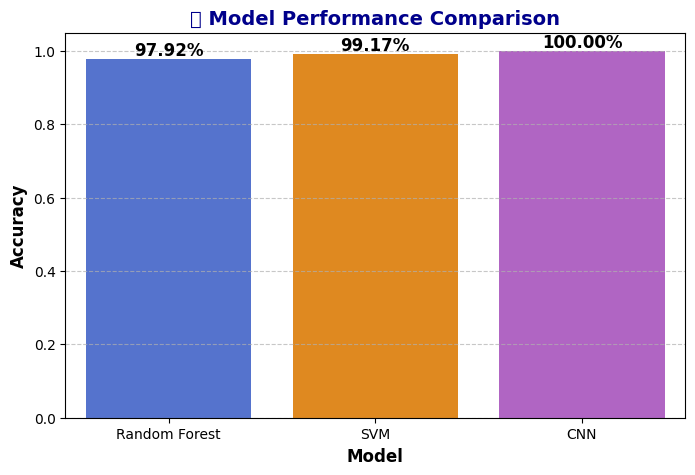

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define a stylish color palette
colors = ["royalblue", "darkorange", "mediumorchid"]  # Blue, Orange, Purple

# Plot Model Performance
plt.figure(figsize=(8, 5))
sns.barplot(x=list(model_accuracies.keys()), y=list(model_accuracies.values()), palette=colors)

# Add numbers on top of bars
for i, acc in enumerate(model_accuracies.values()):
    plt.text(i, acc + 0.01, f"{acc:.2%}", ha='center', fontsize=12, fontweight='bold', color="black")

# Customize labels
plt.xlabel("Model", fontsize=12, fontweight="bold")
plt.ylabel("Accuracy", fontsize=12, fontweight="bold")
plt.title("📊 Model Performance Comparison", fontsize=14, fontweight="bold", color="darkblue")

# Show the grid for better readability
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Display the plot
plt.show()


In [ ]:
import soundfile as sf
import joblib
import librosa
import numpy as np
import os
import tensorflow as tf

# Load the saved scaler
scaler_path = "/content/drive/MyDrive/dataset/scaler.pkl"
scaler = joblib.load(scaler_path)

# Load label encoder
encoder_path = "/content/drive/MyDrive/dataset/encoder.pkl"
encoder = joblib.load(encoder_path)

# Feature extraction function
def extract_features(audio_path):
    y, sr = librosa.load(audio_path, sr=None)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=32)  # Ensure correct number
    return np.mean(mfccs.T, axis=0)

# Prediction function
def predict_audio():
    audio_path = input("🎤 Enter the path to your audio file: ")

    if not os.path.exists(audio_path):
        print("❌ Invalid file path.")
        return

    features = extract_features(audio_path)
    print(f"Feature shape before scaling: {features.shape}")

    # Ensure correct transformation
    features = scaler.transform([features])
    print(f"Feature shape after scaling: {features.shape}")

    # Load the best model (CNN in this case)
    model = tf.keras.models.load_model("/content/drive/MyDrive/dataset/Best_Model_CNN.h5")

    # Ensure correct reshaping
    features = features.reshape(1, 32, 1)  # Adjust according to training data

    # Predict emotion
    prediction = model.predict(features)
    predicted_label = np.argmax(prediction)

    print(f"Predicted Label Index: {predicted_label}")
    print(f"Available Classes in Encoder: {encoder.classes_}")

    # Ensure correct mapping to label
    emotion = encoder.inverse_transform([predicted_label])[0]
    print(f"🎭 Predicted Emotion: {emotion}")

# Run the function
predict_audio()


🎤 Enter the path to your audio file: /content/drive/MyDrive/dataset/TESS_Merged/Anxiety/OAF_dab_fear.wav
Feature shape before scaling: (32,)
Feature shape after scaling: (1, 32)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step
Predicted Label Index: 2
Available Classes in Encoder: ['Anxiety' 'Depression' 'Normal']
🎭 Predicted Emotion: Normal
